<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/week4/Semana_4_%E2%80%93_Actividad_3_FreddyForero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semana 4 – Actividad 3
# Aplicación de Técnicas de Optimización en una Red Neuronal en Google Colab

# Autor: Freddy Alexander Forero Rojas

## Comparación de Optimizadores: Adam vs SGD con Momentum
### Dataset: make_classification (clasificación binaria sintética)

**Objetivo:** Comparar el comportamiento de dos optimizadores durante el entrenamiento
de una red neuronal, observando la evolución del loss y la accuracy en cada época.

**Configuraciones comparadas:**
- `SGD con Momentum` (lr=0.01, momentum=0.9)
- `Adam` (lr=0.001)

**Elementos constantes:** arquitectura, dataset, épocas, batch size, semilla aleatoria.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Semilla para reproducibilidad
np.random.seed(7)
tf.random.set_seed(7)

In [2]:
# Generación del dataset sintético binario
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    random_state=7
)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7, stratify=y
)

# Normalización
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train shape:", X_train_s.shape)
print("Test shape:", X_test_s.shape)

Train shape: (800, 20)
Test shape: (200, 20)


In [3]:
def build_model():
    return keras.Sequential([
        layers.Input(shape=(X_train_s.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

def run(opt, label):
    model = build_model()
    model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
    history = model.fit(
        X_train_s, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0
    )
    test_results = model.evaluate(X_test_s, y_test, verbose=0)
    print(f"\n{label}")
    print(f"  Test Loss:     {test_results[0]:.4f}")
    print(f"  Test Accuracy: {test_results[1]:.4f}")
    return history

# Entrenar con cada optimizador
hist_sgd  = run(keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), "SGD + Momentum")
hist_adam = run(keras.optimizers.Adam(learning_rate=0.001), "Adam")


SGD + Momentum
  Test Loss:     0.2381
  Test Accuracy: 0.9450

Adam
  Test Loss:     0.2622
  Test Accuracy: 0.9450


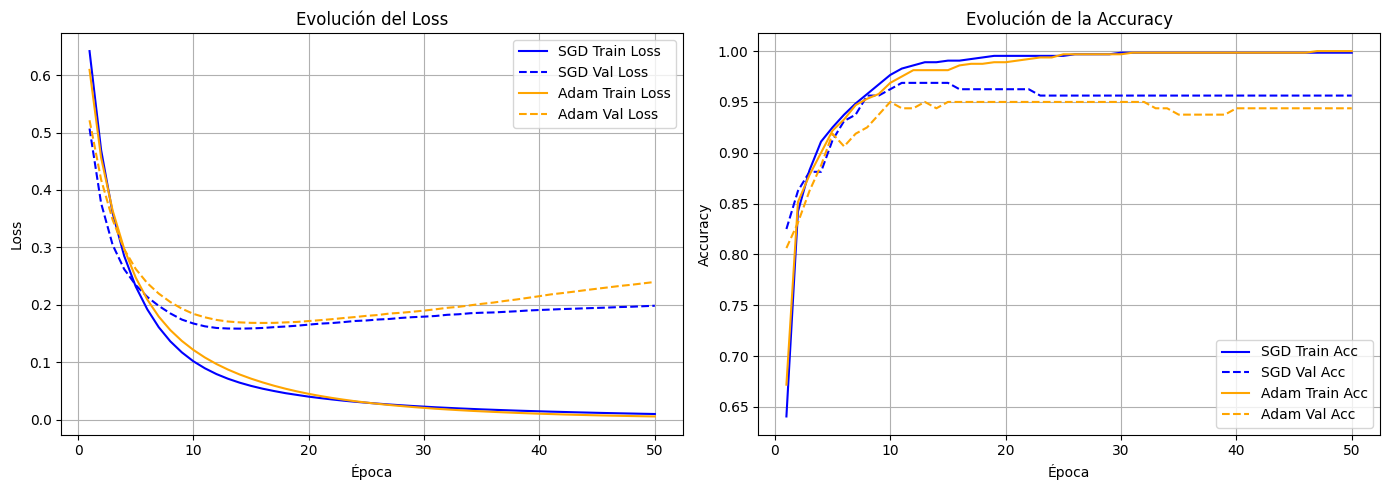

In [4]:
epochs = range(1, 51)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
axes[0].plot(epochs, hist_sgd.history["loss"],     label="SGD Train Loss",  color="blue")
axes[0].plot(epochs, hist_sgd.history["val_loss"], label="SGD Val Loss",    color="blue", linestyle="--")
axes[0].plot(epochs, hist_adam.history["loss"],     label="Adam Train Loss", color="orange")
axes[0].plot(epochs, hist_adam.history["val_loss"], label="Adam Val Loss",   color="orange", linestyle="--")
axes[0].set_title("Evolución del Loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# --- Accuracy ---
axes[1].plot(epochs, hist_sgd.history["accuracy"],     label="SGD Train Acc",  color="blue")
axes[1].plot(epochs, hist_sgd.history["val_accuracy"], label="SGD Val Acc",    color="blue", linestyle="--")
axes[1].plot(epochs, hist_adam.history["accuracy"],     label="Adam Train Acc", color="orange")
axes[1].plot(epochs, hist_adam.history["val_accuracy"], label="Adam Val Acc",   color="orange", linestyle="--")
axes[1].set_title("Evolución de la Accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("comparacion_optimizadores.png", dpi=150)
plt.show()

## Análisis de Resultados

### (i) Diferencias observadas entre configuraciones
- **Adam** mostró una convergencia más rápida desde las primeras épocas, alcanzando
  valores bajos de loss en menos iteraciones.
- **SGD con Momentum** presentó una curva de aprendizaje más gradual pero estable,
  requiriendo más épocas para estabilizarse.

### (ii) Estabilidad y velocidad de convergencia
- Adam converge más rápido gracias a su tasa de aprendizaje adaptativa por parámetro.
- SGD con Momentum es más predecible y menos propenso a oscilaciones bruscas,
  aunque más lento.

### (iii) Principales hallazgos
- Para este dataset sintético, ambos optimizadores alcanzan una accuracy similar al final,
  pero Adam lo hace en menos épocas.
- La brecha entre train loss y val loss fue similar en ambos, indicando que ninguno
  sobreajustó significativamente.
- **Conclusión:** Adam es preferible cuando se busca convergencia rápida. SGD con Momentum
  es una buena alternativa cuando se prioriza estabilidad y control manual del entrenamiento.